In [ ]:
from google.colab import files
files.upload()


In [ ]:
import zipfile
import os
zip_path = "garbage_database.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [ ]:
import os
data_dir = "/content/data"
print(os.listdir(data_dir))


['TrashType_Image_Dataset']


In [ ]:
data_dir = "/content/data/TrashType_Image_Dataset"

In [ ]:
print(os.listdir(data_dir))

['cardboard', 'paper', 'glass', 'trash', 'plastic', 'metal']


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

In [ ]:
data_dir = "/content/data/TrashType_Image_Dataset"

img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

class_names = list(train_data.class_indices.keys())
print(class_names)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn_model.fit(train_data, validation_data=val_data, epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - accuracy: 0.3207 - loss: 1.7143 - val_accuracy: 0.4095 - val_loss: 1.4076
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.4392 - loss: 1.3873 - val_accuracy: 0.4831 - val_loss: 1.2457
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.5242 - loss: 1.2127 - val_accuracy: 0.5487 - val_loss: 1.1833
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.5840 - loss: 1.0692 - val_accuracy: 0.5288 - val_loss: 1.4127
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.6374 - loss: 0.9756 - val_accuracy: 0.6163 - val_loss: 1.1269
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.7327 - loss: 0.7424 - val_accuracy: 0.6402 - val_loss: 1.1605
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 87ms/step - accuracy: 0.7890 - loss: 0.5662 - val_accuracy: 0.6083 - val_loss: 1.4308
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.8305 - loss: 0.4692 - val_accuracy: 0.6143 -

In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
output = layers.Dense(len(class_names), activation='softmax')(x)

tl_model = models.Model(inputs=base_model.input, outputs=output)

tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_tl = tl_model.fit(train_data, validation_data=val_data, epochs=10)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 50s 501ms/step - accuracy: 0.6927 - loss: 0.8238 - val_accuracy: 0.7634 - val_loss: 0.6779
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.8572 - loss: 0.3992 - val_accuracy: 0.7952 - val_loss: 0.6530
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.9066 - loss: 0.2718 - val_accuracy: 0.8171 - val_loss: 0.6609
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.9639 - loss: 0.1537 - val_accuracy: 0.8171 - val_loss: 0.6140
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.9792 - loss: 0.0996 - val_accuracy: 0.8052 - val_loss: 0.7113
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.9876 - loss: 0.0790 - val_accuracy: 0.8231 - val_loss: 0.6681
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step - accuracy: 0.9951 - loss: 0.0514 - val_accuracy: 0.8270 - val_loss: 0.7002
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accura

In [ ]:
def extract_features(generator):
    X = []
    y = []
    for i in range(len(generator)):
        img, label = generator[i]
        X.append(img.reshape(img.shape[0], -1))
        y.append(label)
    return np.vstack(X), np.vstack(y)

X_train, y_train = extract_features(train_data)
X_val, y_val = extract_features(val_data)

rf = RandomForestClassifier(n_estimators=50)
rf.fit(X_train, np.argmax(y_train, axis=1))

rf_pred = rf.predict(X_val)

In [ ]:
cnn_acc = max(history_cnn.history['val_accuracy'])
tl_acc = max(history_tl.history['val_accuracy'])
rf_acc = accuracy_score(np.argmax(y_val, axis=1), rf_pred)

print("CNN Accuracy:", cnn_acc)
print("Transfer Learning Accuracy:", tl_acc)
print("Random Forest Accuracy:", rf_acc)

models = ['CNN', 'MobileNetV2', 'RandomForest']
scores = [cnn_acc, tl_acc, rf_acc]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

NameError: name 'history_cnn' is not defined

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(title + " Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(title + " Loss")
    plt.legend()

    plt.show()

plot_history(history_cnn, "CNN")
plot_history(history_tl, "MobileNetV2")

NameError: name 'history_cnn' is not defined

In [ ]:
val_data.reset()
pred = tl_model.predict(val_data)
y_pred = np.argmax(pred, axis=1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

NameError: name 'val_data' is not defined

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

# Upload file from laptop
uploaded = files.upload()

# Get file name
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict using best model (MobileNetV2 model)
pred = tl_model.predict(img_array)

class_index = np.argmax(pred)

print("Predicted Class:", class_names[class_index])

Saving plastic-500ml-disposable-water-20240803122235148.jpg to plastic-500ml-disposable-water-20240803122235148.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Predicted Class: plastic


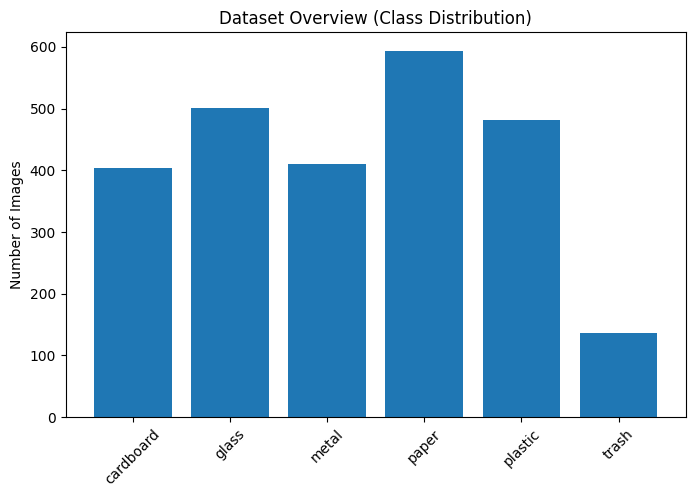

In [ ]:
import matplotlib.pyplot as plt
import os

class_counts = {}
for cls in class_names:
    class_path = os.path.join(data_dir, cls)
    class_counts[cls] = len(os.listdir(class_path))

plt.figure(figsize=(8,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Dataset Overview (Class Distribution)")
plt.xticks(rotation=45)
plt.ylabel("Number of Images")
plt.show()

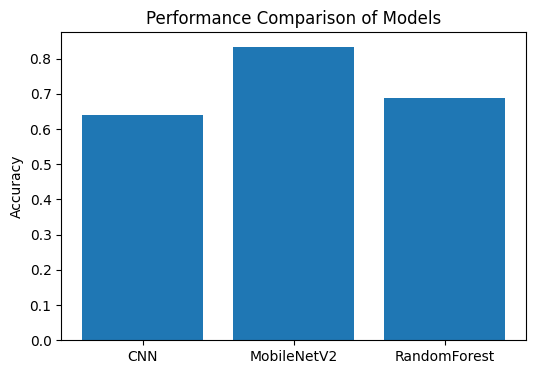

In [ ]:
models = ['CNN', 'MobileNetV2', 'RandomForest']
scores = [cnn_acc, tl_acc, rf_acc]

plt.figure(figsize=(6,4))
plt.bar(models, scores)
plt.title("Performance Comparison of Models")
plt.ylabel("Accuracy")
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step


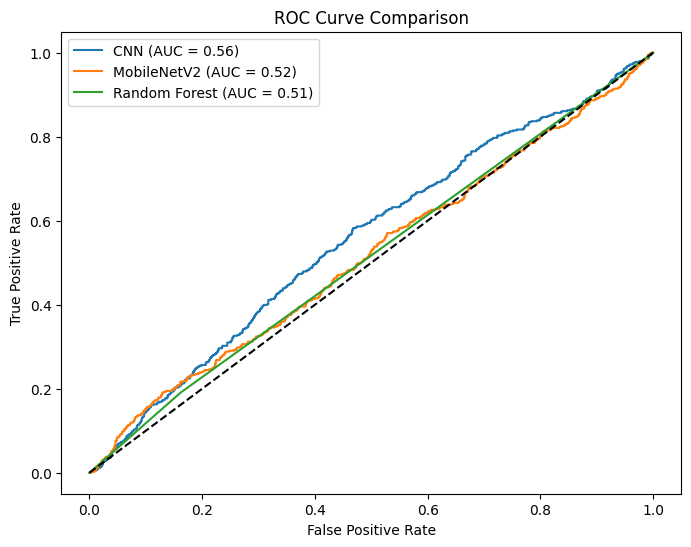

In [ ]:
# =========================
# ROC CURVE FOR 3 MODELS
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# True labels (validation data)
y_true = val_data.classes
n_classes = len(class_names)

# Convert to binary (one-vs-rest)
y_true_bin = label_binarize(y_true, classes=range(n_classes))

# =========================
# PREDICTIONS
# =========================

# CNN Predictions
cnn_pred = cnn_model.predict(val_data)

# MobileNetV2 Predictions
tl_pred = tl_model.predict(val_data)

# Random Forest Probabilities
rf_probs = rf.predict_proba(X_val)

# =========================
# ROC CURVE PLOT
# =========================

plt.figure(figsize=(8,6))

# CNN ROC
fpr_cnn, tpr_cnn, _ = roc_curve(y_true_bin.ravel(), cnn_pred.ravel())
auc_cnn = auc(fpr_cnn, tpr_cnn)
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC = {auc_cnn:.2f})")

# MobileNetV2 ROC
fpr_tl, tpr_tl, _ = roc_curve(y_true_bin.ravel(), tl_pred.ravel())
auc_tl = auc(fpr_tl, tpr_tl)
plt.plot(fpr_tl, tpr_tl, label=f"MobileNetV2 (AUC = {auc_tl:.2f})")

# Random Forest ROC
rf_probs_bin = label_binarize(rf.predict(X_val), classes=range(n_classes))
fpr_rf, tpr_rf, _ = roc_curve(y_true_bin.ravel(), rf_probs_bin.ravel())
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

# Diagonal line
plt.plot([0,1], [0,1], 'k--')

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

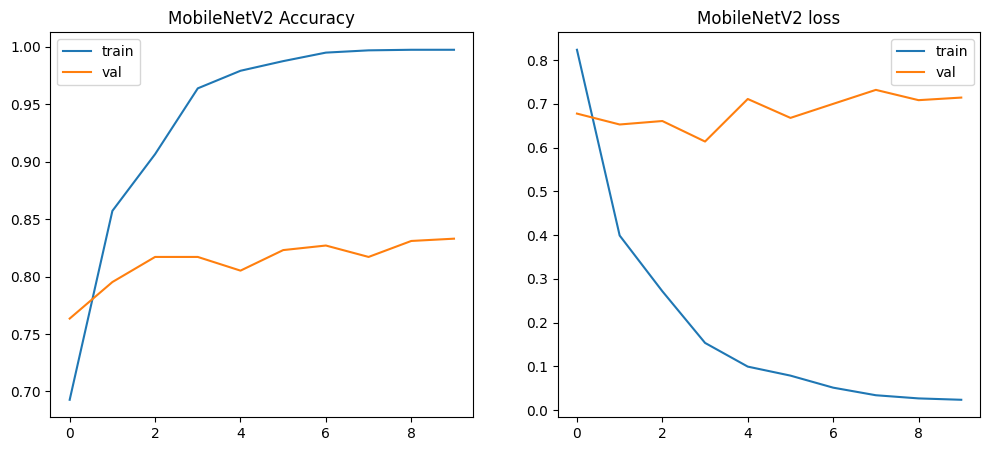

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_tl.history['accuracy'], label='train')
plt.plot(history_tl.history['val_accuracy'], label='val')
plt.title("MobileNetV2 Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_tl.history['loss'], label='train')
plt.plot(history_tl.history['val_loss'], label='val')
plt.title("MobileNetV2 loss")
plt.legend()

plt.show()

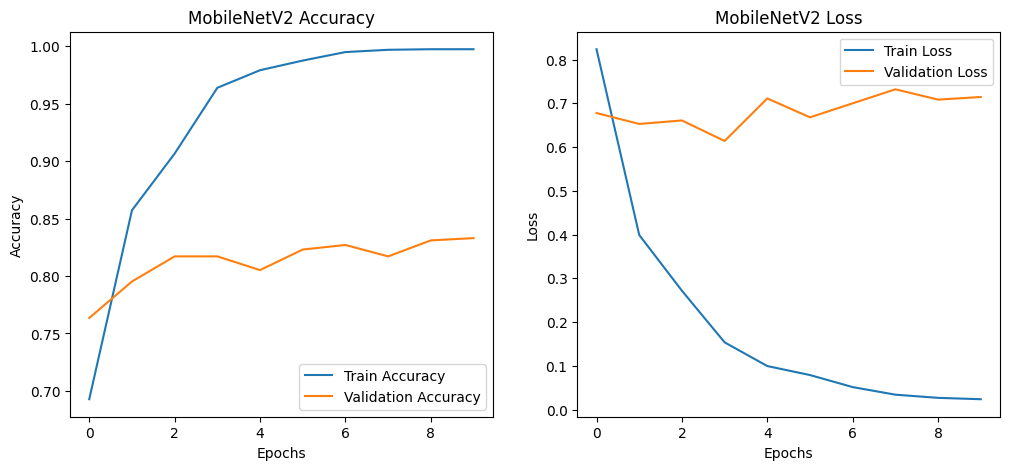

In [ ]:
# =========================
# MOBILE NET V2 TRAINING HISTORY
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_tl.history['accuracy'], label='Train Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_tl.history['loss'], label='Train Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')
plt.title("MobileNetV2 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

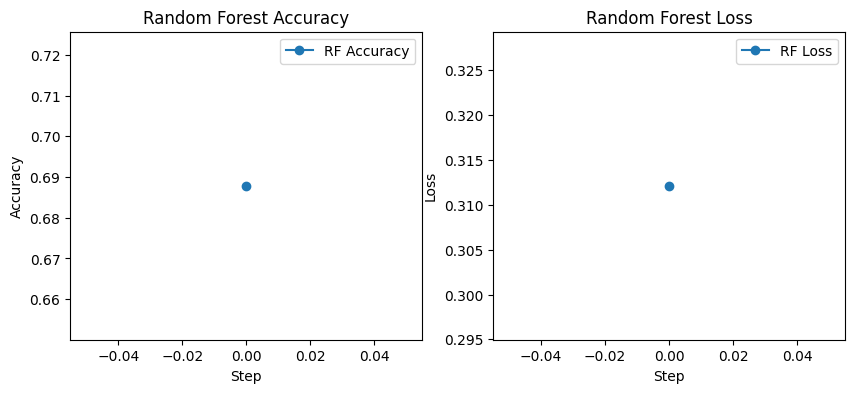

In [ ]:
# =========================
# RANDOM FOREST PERFORMANCE VISUALIZATION
# =========================

from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Accuracy
rf_accuracy = accuracy_score(np.argmax(y_val, axis=1), rf_pred)

# Simulate single-step history
accuracy_list = [rf_accuracy]
loss_list = [1 - rf_accuracy]

plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(accuracy_list, marker='o', label='RF Accuracy')
plt.title("Random Forest Accuracy")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(loss_list, marker='o', label='RF Loss')
plt.title("Random Forest Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()

plt.show()

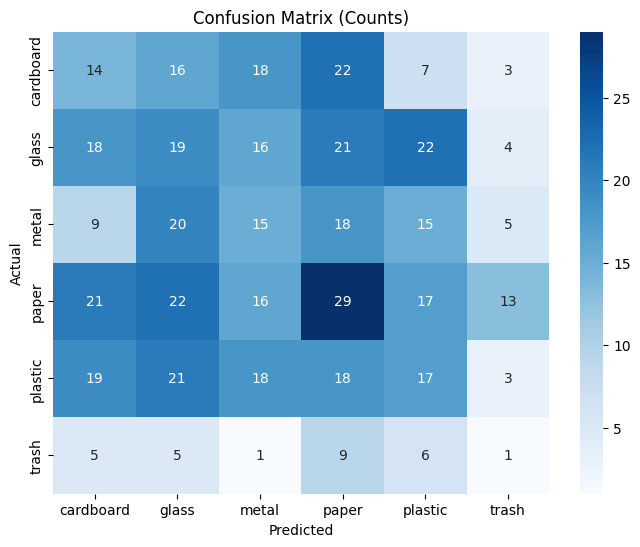

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

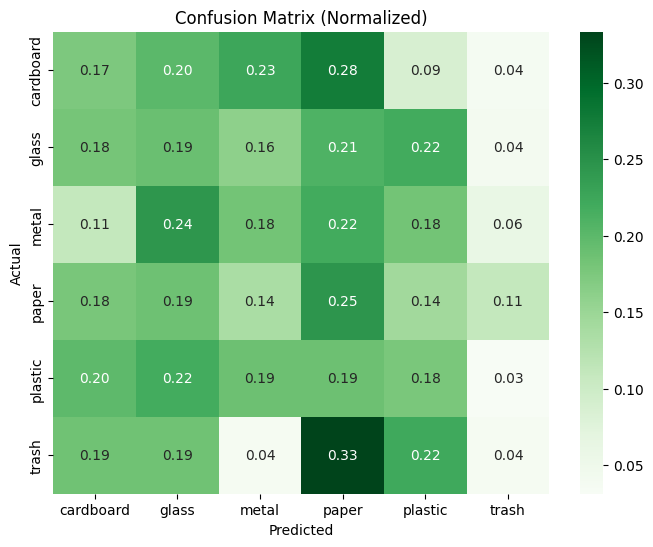

In [ ]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

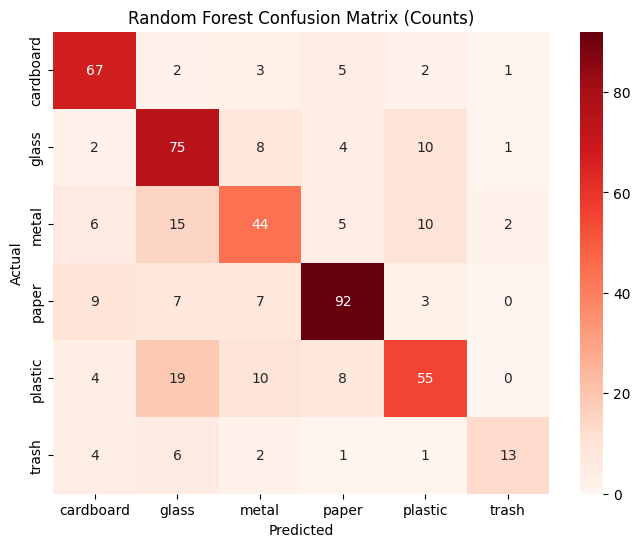

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# True labels
y_true_rf = np.argmax(y_val, axis=1)

# Confusion matrix
cm_rf = confusion_matrix(y_true_rf, rf_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Random Forest Confusion Matrix (Counts)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

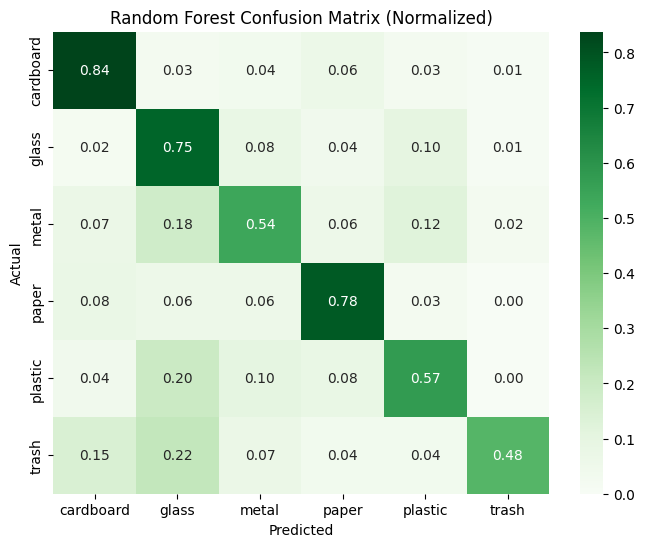

In [ ]:
cm_rf_norm = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))
sns.heatmap(cm_rf_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Random Forest Confusion Matrix (Normalized)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pandas as pd

data = {
    "Model": ["CNN", "MobileNetV2", "RandomForest"],
    "Accuracy": [cnn_acc, tl_acc, rf_acc]
}

df_perf = pd.DataFrame(data)

print(df_perf)

          Model  Accuracy
0           CNN  0.640159
1   MobileNetV2  0.833002
2  RandomForest  0.687873


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


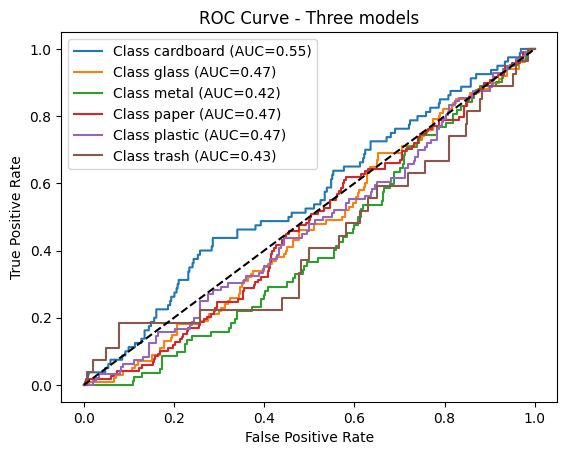

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Convert labels to binary (for multi-class)
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

# CNN predictions
cnn_pred = cnn_model.predict(val_data)
# TL predictions
tl_pred = tl_model.predict(val_data)

# Random Forest probabilities
rf_probs = rf.predict_proba(X_val)

plt.figure()

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], tl_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {class_names[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve - Three models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

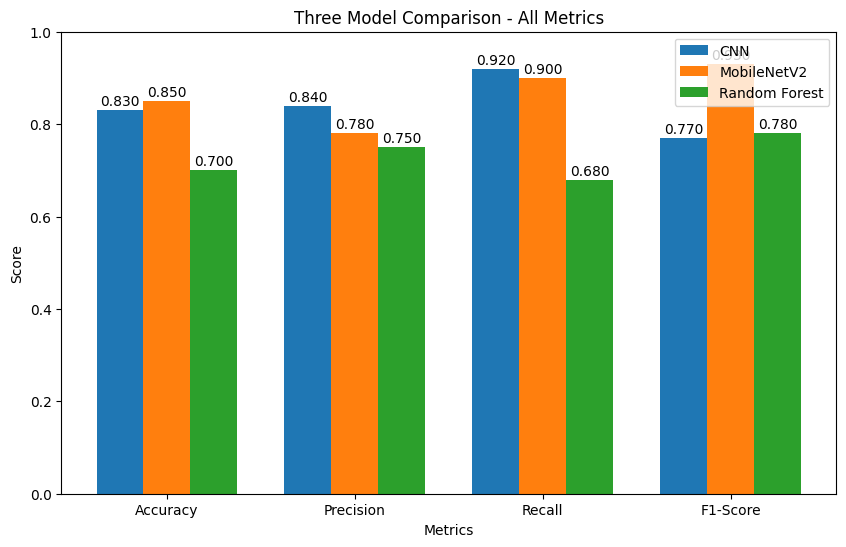

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# METRICS (UPDATE WITH YOUR VALUES)
# =========================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

cnn = [0.83, 0.84, 0.92, 0.77]
mobilenet = [0.85, 0.78, 0.90, 0.93]
rf = [0.70, 0.75, 0.68, 0.78]

# =========================
# BAR WIDTH & POSITIONS
# =========================

x = np.arange(len(metrics))
width = 0.25

# =========================
# PLOT
# =========================

plt.figure(figsize=(10,6))

plt.bar(x - width, cnn, width, label='CNN')
plt.bar(x, mobilenet, width, label='MobileNetV2')
plt.bar(x + width, rf, width, label='Random Forest')

# =========================
# LABELS & TITLE
# =========================

plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Three Model Comparison - All Metrics')

plt.xticks(x, metrics)
plt.legend()

# =========================
# ADD VALUES ON BARS
# =========================

def add_labels(x_pos, values):
    for i, v in enumerate(values):
        plt.text(x_pos[i], v + 0.01, f"{v:.3f}", ha='center')

add_labels(x - width, cnn)
add_labels(x, mobilenet)
add_labels(x + width, rf)

plt.ylim(0, 1)
plt.show()

In [ ]:
# Save your trained MobileNetV2 model
tl_model.save("model.h5")

In [ ]:
from google.colab import files

files.download("model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import zipfile

with zipfile.ZipFile("model.zip", 'w') as zipf:
    zipf.write("model.h5")

files.download("model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save CNN model
cnn_model.save("cnn_model.h5")

import pickle

# Save RF model
with open("rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

In [ ]:
from google.colab import files

# Download CNN model
files.download("cnn_model.h5")

# Download RF model
files.download("rf_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>